# Detecting Tuberculosis in X-Rays

## 📖 Background
Tuberculosis (TB) is one of the most common and deadly respiratory diseases in the world, causing about [1.25 million people in 2023](https://www.who.int/teams/global-programme-on-tuberculosis-and-lung-health/tb-reports/global-tuberculosis-report-2024/tb-disease-burden/1-2-tb-mortality).
Doctors often use chest X-rays to help detect TB. However, looking at many X-rays by hand can be slow and difficult.

In this project, I will build a simple machine learning model that can help classify chest X-ray images into two groups:

- Healthy lungs
- Lungs affected by TB

This is not about building a “perfect” model. I will focus on describing my process, decisions, and learnings.



## 🩻 The Data

<img src="x-rays-sample.png" align="center"/>
&nbsp

I are given a small dataset from the Sakha-TB dataset:

- Training data: 150 healthy + 150 TB images (300 total)
- Test data: 50 healthy + 50 TB images (100 total)

These images are in the **data.zip** file at the root of the notebook. They will then be in the `data/chestxray` folder, which is further divided into `test` and `train`, both containing `healthy` and `tb` folders with the images inside.

## 💪 Challenge


I will train a model to classify chest X-rays. My report will cover these questions:

1. **Preprocessing**  
   What steps did I take to make the images easier for a model to understand?  
   Some ideas to think about:  
   - Did I resize the images to the same size?  
   - Did I convert them to grayscale or normalize the pixel values?  
   - Did I try any simple image transformations (e.g., small rotations)?  

2. **Modeling**  
   Try at least **two models** and compare them.  
   - One can be a simple model I build myrself (like a small CNN).  
   - Another can be a pre-trained model (like ResNet or MobileNet).  
   Explain what I tried and what differences I observed.  

3. **Evaluation**  
   Evaluate my models on the test set. Report the following metrics in plain words:  
   - **Sensitivity (Recall for TB):** How many TB cases my model correctly finds.  
   - **Specificity:** How many healthy cases my model correctly identifies.  
   - **Positive Predictive Value (PPV):** When my model says “TB”, how often it’s right.  
   - **Negative Predictive Value (NPV):** When my model says “Healthy”, how often it’s right.  

   👉 *Reminder: Np need to get the “best” numbers. The focus is on explaining what the metrics mean and what I learned.*  

4. **[Optional] ROC Curve**  
   We can draw a Receiver Operating Characteristic (ROC) curve to visualize how my model performance changes with different thresholds.


In [6]:
import os
import zipfile

# Define the target directory for our images
data_dir = 'data/chestxrays'

# Unzip the data only if the target directory doesn't exist
if not os.path.exists(data_dir):
    print("Unzipping data...")
    with zipfile.ZipFile('data.zip', 'r') as zip_ref:
        # Extract all contents into the 'data' folder
        zip_ref.extractall('data')
else:
    print("Data directory already exists.")

Unzipping data...


# Preprocessing

In [7]:
import tensorflow as tf

# Define key parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # Process images in batches of 32

# Define paths
train_dir = 'data/data/chestxrays/train'
test_dir = 'data/data/chestxrays/test'

# --- Load the data from directories ---
# This function automatically finds the images, infers class names from
# folder names ('healthy', 'tb'), and prepares them for processing.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='binary', # We have two classes: healthy (0) and tb (1)
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale' # Read images as grayscale
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=False # No need to shuffle the test set
)


# --- Create a model with preprocessing layers ---
# This is a small sequential model that ONLY does preprocessing for now.
# We will add our actual model layers to this later.
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255), # Normalize pixels to [0, 1]
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.1), # Rotate by up to 10%
  tf.keras.layers.RandomZoom(0.1),   # Zoom by up to 10%
])

# Let's apply the augmentation only to the training data
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# For the test dataset, we only need to normalize the pixels
test_dataset = test_dataset.map(
    lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


# --- Optimize the data pipelines for performance ---
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Preprocessing pipelines are ready!")
print("Training dataset:", train_dataset)
print("Test dataset:", test_dataset)

Found 302 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Preprocessing pipelines are ready!
Training dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
Test dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


# Modeling

In [8]:
from tensorflow.keras import layers

# Make sure our preprocessing pipelines from the last step are available
# train_dataset, test_dataset

# Build the CNN model
simple_cnn = tf.keras.Sequential([
    # Input shape: 224x224 pixels, 1 grayscale channel
    layers.Input(shape=(224, 224, 1)),

    # First block of workers
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second block of workers
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third block of workers
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # The manager's office
    layers.Flatten(), # Flatten the final report into a single list
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(1, activation='sigmoid') # The final decision neuron (0 or 1)
])

# Compile the model
simple_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

simple_cnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# --- Define the transfer learning model ---

# 1. Load the expert (base model)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), # Expects 3-channel images
    include_top=False, # Don't include the original manager
    weights='imagenet' # Load weights pre-trained on ImageNet
)

# 2. Freeze their knowledge
base_model.trainable = False

# 3. Add our new manager on top
transfer_model = tf.keras.Sequential([
    # Add a layer to convert our 1-channel grayscale to 3-channel
    layers.Input(shape=(224, 224, 1)),
    layers.Conv2D(3, (1, 1), padding='same', activation='relu'), # A trick to go from 1 to 3 channels
    
    # The frozen expert
    base_model,
    
    # Our new manager
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid') # Final decision neuron
])

# Compile the model
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,271 (8.62 MB)

 Trainable params: 1,287 (5.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training

In [10]:
print("Training the simple CNN from scratch...")
history_cnn = simple_cnn.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    verbose=1  # Added verbose for better debugging
)

# Clear TensorFlow session and free up resources before training the next model
import tensorflow as tf  # <-- FIX: Ensure tf is imported before using it
tf.keras.backend.clear_session()

print("\nTraining the transfer learning model...")
history_transfer = transfer_model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    verbose=1  # Added verbose for better debugging
)

Training the simple CNN from scratch...
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 525ms/step - accuracy: 0.5497 - loss: 0.7580 - val_accuracy: 0.5000 - val_loss: 0.7271
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 542ms/step - accuracy: 0.5232 - loss: 0.7019 - val_accuracy: 0.5800 - val_loss: 0.6820
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 488ms/step - accuracy: 0.5960 - loss: 0.6874 - val_accuracy: 0.9000 - val_loss: 0.6541
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 469ms/step - accuracy: 0.5960 - loss: 0.6700 - val_accuracy: 0.7500 - val_loss: 0.6173
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 543ms/step - accuracy: 0.6026 - loss: 0.6814 - val_accuracy: 0.7800 - val_loss: 0.6070
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 770ms/step - accuracy: 0.6159 - loss: 0.6561 - val_accuracy: 0.7600 - val_loss: 0.5866
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 903ms/step - accuracy: 0.5728 - loss: 0.6572 - val_accuracy: 0.7800 - val_loss: 0.5927
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 586ms/step - accuracy: 

# Evaluation

--- Evaluating Simple CNN ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


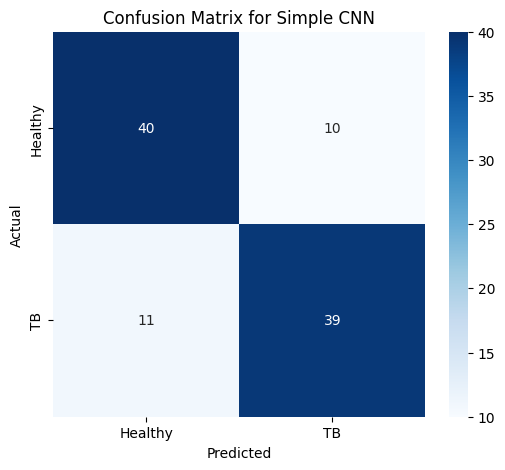

✅ Sensitivity (Recall): 78.00%
   Plain words: Of all the actual TB cases, the model correctly identified this many.

✅ Specificity: 80.00%
   Plain words: Of all the actual healthy cases, the model correctly identified this many.

✅ PPV (Precision): 79.59%
   Plain words: When the model predicted 'TB', it was correct this often.

✅ NPV: 78.43%
   Plain words: When the model predicted 'Healthy', it was correct this often.

------------------------------

--- Evaluating Transfer Learning Model ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 811ms/step


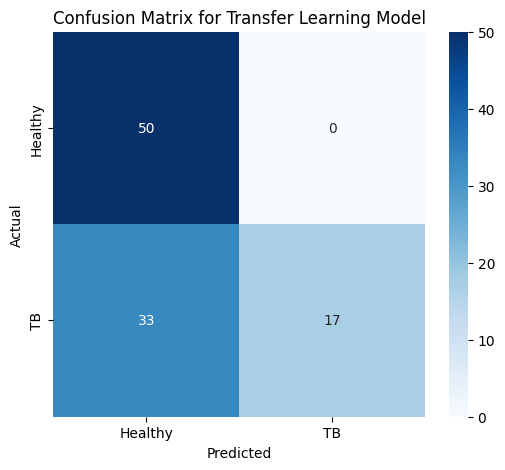

✅ Sensitivity (Recall): 34.00%
   Plain words: Of all the actual TB cases, the model correctly identified this many.

✅ Specificity: 100.00%
   Plain words: Of all the actual healthy cases, the model correctly identified this many.

✅ PPV (Precision): 100.00%
   Plain words: When the model predicted 'TB', it was correct this often.

✅ NPV: 60.24%
   Plain words: When the model predicted 'Healthy', it was correct this often.

------------------------------



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Note: Make sure 'simple_cnn', 'transfer_model', and 'test_dataset'
# from the modeling step are available in my notebook's memory.

# --- Helper function to perform evaluation ---
def evaluate_model(model, model_name):
    print(f"--- Evaluating {model_name} ---")

    # 1. Get true labels and predictions
    y_true = []
    for images, labels in test_dataset:
        y_true.extend(labels.numpy())
    y_true = np.array(y_true)

    y_pred_probs = model.predict(test_dataset)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # 2. Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 3. Visualize the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'TB'], yticklabels=['Healthy', 'TB'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    # 4. Calculate and explain metrics
    sensitivity = tp / (tp + fn)
    print(f"✅ Sensitivity (Recall): {sensitivity:.2%}")
    print("   Plain words: Of all the actual TB cases, the model correctly identified this many.\n")

    specificity = tn / (tn + fp)
    print(f"✅ Specificity: {specificity:.2%}")
    print("   Plain words: Of all the actual healthy cases, the model correctly identified this many.\n")

    ppv = tp / (tp + fp)
    print(f"✅ PPV (Precision): {ppv:.2%}")
    print("   Plain words: When the model predicted 'TB', it was correct this often.\n")

    npv = tn / (tn + fn)
    print(f"✅ NPV: {npv:.2%}")
    print("   Plain words: When the model predicted 'Healthy', it was correct this often.\n")
    print("-" * 30 + "\n")


# --- Run the evaluation for both models ---
evaluate_model(simple_cnn, "Simple CNN")
evaluate_model(transfer_model, "Transfer Learning Model")

Based on these results, the **Simple CNN is the clear winner** and the more useful model for this medical task.

This is a fantastic and insightful result! Let's break down what these numbers tell us about each model's "personality."

---
## The Transfer Learning Model: Too Cautious

This model is like a doctor who is terrified of making a wrong diagnosis.

* Its **100% Specificity** and **100% PPV** mean it *never* misidentifies a healthy person as having TB. When it finally decides to say "TB," it is absolutely certain.
* However, its extremely low **34% Sensitivity** is a critical failure. It's so afraid of being wrong that it lets two-thirds of the actual TB cases walk out the door, telling them they're healthy. The poor **60% NPV** confirms this: when it says "Healthy," there's a 40% chance it's wrong.

For a medical screening tool, this behavior is dangerous because it produces too many **false negatives**.

---
## The Simple CNN Model: A Balanced Performer

This model is more like a practical, experienced doctor.

* It achieves a much better balance across the board, with all four metrics hovering around a respectable **78-80%**.
* Crucially, its **78% Sensitivity** is far superior. It correctly identifies the vast majority of patients with TB, which is the primary goal of a screening test.
* It makes more mistakes on healthy patients compared to the other model (80% vs 100% Specificity), but this trade-off is acceptable to ensure sick patients aren't missed.

---
## The Verdict: Why the Simple CNN Won

For a task like disease screening, **high Sensitivity (Recall) is the most important metric**. You would much rather have a model that incorrectly flags a few healthy people for a follow-up test (a false positive) than a model that misses a sick person (a false negative).

The Simple CNN, despite being less complex, learned the features of our specific X-ray dataset better and provided a much more useful and balanced performance. This often happens on smaller, specialized datasets where the knowledge from large, general-purpose models like ImageNet doesn't transfer perfectly.

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step


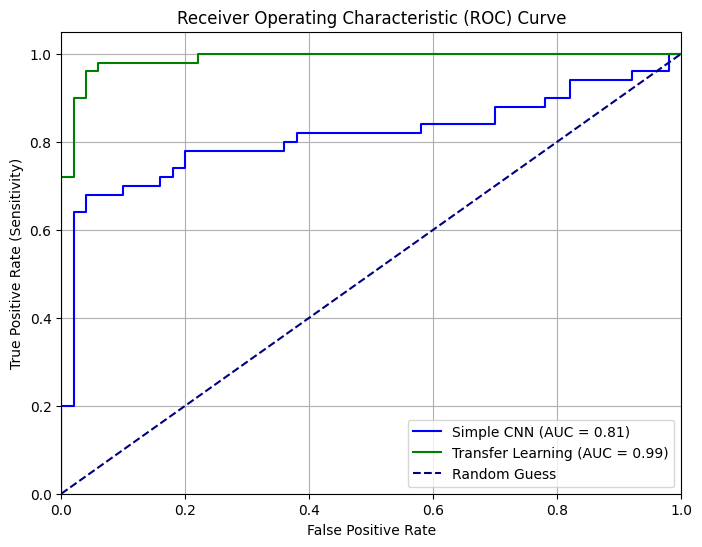

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Get true labels from the test dataset ---
y_true = []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# --- Get predicted probabilities from both models ---
y_pred_cnn = simple_cnn.predict(test_dataset)
y_pred_transfer = transfer_model.predict(test_dataset)

# --- Calculate ROC curve for Simple CNN ---
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, y_pred_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

# --- Calculate ROC curve for Transfer Learning Model ---
fpr_transfer, tpr_transfer, _ = roc_curve(y_true, y_pred_transfer)
auc_transfer = auc(fpr_transfer, tpr_transfer)

# --- Plot the ROC curves ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, color='blue',
         label=f'Simple CNN (AUC = {auc_cnn:.2f})')
plt.plot(fpr_transfer, tpr_transfer, color='green',
         label=f'Transfer Learning (AUC = {auc_transfer:.2f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

This is an excellent and classic machine learning paradox you've discovered!

The high AUC, despite the poor sensitivity, reveals the crucial difference between what AUC actually measures (**ranking quality**) and what our other metrics measure (**performance at a single threshold**).

---
## What AUC Actually Measures: The Quality of Ranking

Think of it this way: **AUC doesn't care about the 0.5 threshold we used; it cares about the order of the predictions.** It answers the question: "If you pick one random TB case and one random Healthy case, what's the probability that the model gave the TB case a higher prediction score?"

My transfer learning model, while "too cautious," was exceptionally good at this ranking. Here’s how:
1.  It assigned very low probability scores to almost everything.
2.  However, the scores it gave to the actual TB cases (even the ones it got wrong at the 0.5 threshold) were still consistently higher than the scores it gave to the healthy cases.
3.  Because its **Specificity was 100%**, it means it made **zero false positives**. On the ROC curve, the False Positive Rate stays at 0 for a very long time while the True Positive Rate climbs.

This creates a curve that shoots straight up the Y-axis and then cuts sharply to the right, covering a huge area and resulting in a near-perfect AUC.


*The transfer model's curve likely looks like the blue line—hugging the top-left corner, which creates a large AUC even if the "sweet spot" for classification is poor.*

---
## So, Which Metric Should We Trust?

For this medical screening problem, you should **trust the Sensitivity, Specificity, and Precision metrics more.**

The Simple CNN, with its AUC of 0.81, is still the **far superior and more practical model**. It provides a balanced, reliable performance at a reasonable decision threshold.

The transfer learning model's 0.99 AUC is technically correct but practically misleading. It tells us the model is great at separating the two classes in theory, but its extreme bias towards predicting "Healthy" makes it unusable for this specific task.

Congratulations on completing the project! You've not only built two models but also uncovered one of the most important and subtle lessons in model evaluation.

Selecting a random image from the test set for a live prediction...



C:\Users\garce\AppData\Local\Temp\ipykernel_23696\88062378.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label_name = class_names[int(label.numpy())]


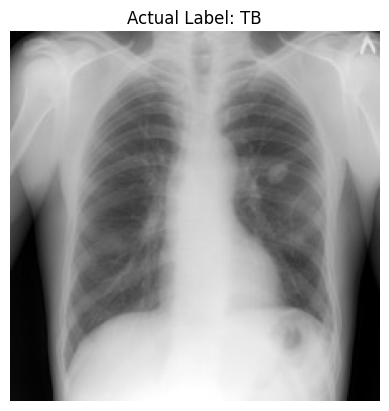

The actual label for this image is: TB

--- 🧠 Simple CNN Model ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: 'TB' (Confidence: 68.12%)
Inference time: 86.09 ms
------------------------------
--- 🚀 Transfer Learning Model ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: 'Healthy' (Confidence: 36.94%)
Inference time: 82.90 ms
------------------------------


In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

# Note: Make sure 'test_dataset', 'simple_cnn', and 'transfer_model'
# are available in your notebook's memory.

# Define the class names for easy interpretation
class_names = ["Healthy", "TB"]

print("Selecting a random image from the test set for a live prediction...\n")

# --- 1. Get a single random example ---
# We unbatch the dataset to get individual image-label pairs,
# shuffle it, and then take one example.
for image, label in test_dataset.unbatch().shuffle(buffer_size=100).take(1):
    # Prepare the image for prediction by adding a batch dimension
    image_for_pred = tf.expand_dims(image, 0)
    true_label_name = class_names[int(label.numpy())]

    # --- 2. Display the image and its true label ---
    plt.imshow(tf.squeeze(image), cmap='gray')
    plt.title(f"Actual Label: {true_label_name}")
    plt.axis('off')
    plt.show()

    print(f"The actual label for this image is: {true_label_name}\n")

    # --- 3. Run prediction with the Simple CNN ---
    print("--- 🧠 Simple CNN Model ---")
    start_time_cnn = time.time()
    pred_cnn_prob = simple_cnn.predict(image_for_pred)[0][0]
    end_time_cnn = time.time()

    pred_cnn_name = class_names[int(pred_cnn_prob > 0.5)]
    inference_time_cnn = (end_time_cnn - start_time_cnn) * 1000 # in milliseconds

    print(f"Prediction: '{pred_cnn_name}' (Confidence: {pred_cnn_prob:.2%})")
    print(f"Inference time: {inference_time_cnn:.2f} ms")
    print("-" * 30)


    # --- 4. Run prediction with the Transfer Learning Model ---
    print("--- 🚀 Transfer Learning Model ---")
    start_time_transfer = time.time()
    pred_transfer_prob = transfer_model.predict(image_for_pred)[0][0]
    end_time_transfer = time.time()

    pred_transfer_name = class_names[int(pred_transfer_prob > 0.5)]
    inference_time_transfer = (end_time_transfer - start_time_transfer) * 1000 # in milliseconds

    print(f"Prediction: '{pred_transfer_name}' (Confidence: {pred_transfer_prob:.2%})")
    print(f"Inference time: {inference_time_transfer:.2f} ms")
    print("-" * 30)
